In [ ]:
!pip install -q tabulate scikit-image opencv-python-headless matplotlib numpy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.metrics import structural_similarity as ssim

In [ ]:
BASE_PATH = "/content/drive/MyDrive/lol_dataset/our485"

LOW_FOLDER = os.path.join(BASE_PATH, "low")
HIGH_FOLDER = os.path.join(BASE_PATH, "high")

print("LOW PATH :", LOW_FOLDER)
print("HIGH PATH:", HIGH_FOLDER)

LOW PATH : /content/drive/MyDrive/lol_dataset/our485/low
HIGH PATH: /content/drive/MyDrive/lol_dataset/our485/high


In [ ]:
low_images = sorted(os.listdir(LOW_FOLDER))
high_images = sorted(os.listdir(HIGH_FOLDER))

print("Low images :", len(low_images))
print("High images:", len(high_images))

print("First 5 images:")
print(low_images[:5])

Low images : 485
High images: 485
First 5 images:
['10.png', '100.png', '101.png', '102.png', '103.png']


In [ ]:
FILES = sorted(os.listdir(LOW_FOLDER))[:20]

print("Number of selected images:", len(FILES))

Number of selected images: 20


In [ ]:
def apply_gamma(image, gamma=1.5):
    normalized = image / 255.0
    corrected = np.power(normalized, gamma)
    corrected = np.uint8(corrected * 255)
    return corrected

In [ ]:
def apply_histogram_equalization(image):
    return cv2.equalizeHist(image)

In [ ]:
def apply_clahe(image):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    return clahe.apply(image)

In [ ]:
def compute_metrics(processed, reference):
    mse = np.mean((processed - reference) ** 2)

    if mse == 0:
        psnr = 100
    else:
        psnr = 20 * np.log10(255.0 / np.sqrt(mse))

    ssim_score = ssim(processed, reference)

    return mse, psnr, ssim_score

In [ ]:
gamma_results = []
hist_results = []
clahe_results = []

for fname in FILES:

    low_path = os.path.join(LOW_FOLDER, fname)
    high_path = os.path.join(HIGH_FOLDER, fname)

    low = cv2.imread(low_path, cv2.IMREAD_GRAYSCALE)
    high = cv2.imread(high_path, cv2.IMREAD_GRAYSCALE)

    gamma_img = apply_gamma(low, gamma=1.5)
    hist_img = apply_histogram_equalization(low)
    clahe_img = apply_clahe(low)

    gamma_metrics = compute_metrics(gamma_img, high)
    hist_metrics = compute_metrics(hist_img, high)
    clahe_metrics = compute_metrics(clahe_img, high)

    gamma_results.append(gamma_metrics)
    hist_results.append(hist_metrics)
    clahe_results.append(clahe_metrics)

In [ ]:
def average_metrics(results):
    mse_avg = np.mean([x[0] for x in results])
    psnr_avg = np.mean([x[1] for x in results])
    ssim_avg = np.mean([x[2] for x in results])

    return mse_avg, psnr_avg, ssim_avg


gamma_avg = average_metrics(gamma_results)
hist_avg = average_metrics(hist_results)
clahe_avg = average_metrics(clahe_results)

print("Gamma Correction")
print("MSE :", gamma_avg[0])
print("PSNR:", gamma_avg[1])
print("SSIM:", gamma_avg[2])

print("\nHistogram Equalization")
print("MSE :", hist_avg[0])
print("PSNR:", hist_avg[1])
print("SSIM:", hist_avg[2])

print("\nCLAHE")
print("MSE :", clahe_avg[0])
print("PSNR:", clahe_avg[1])
print("SSIM:", clahe_avg[2])

Gamma Correction
MSE : 109.52194520833332
PSNR: 27.74333443637021
SSIM: 0.03494517964258329

Histogram Equalization
MSE : 107.11402666666666
PSNR: 27.837450209056033
SSIM: 0.36917868490234074

CLAHE
MSE : 107.06002854166668
PSNR: 27.8443142048979
SSIM: 0.3212135067293508


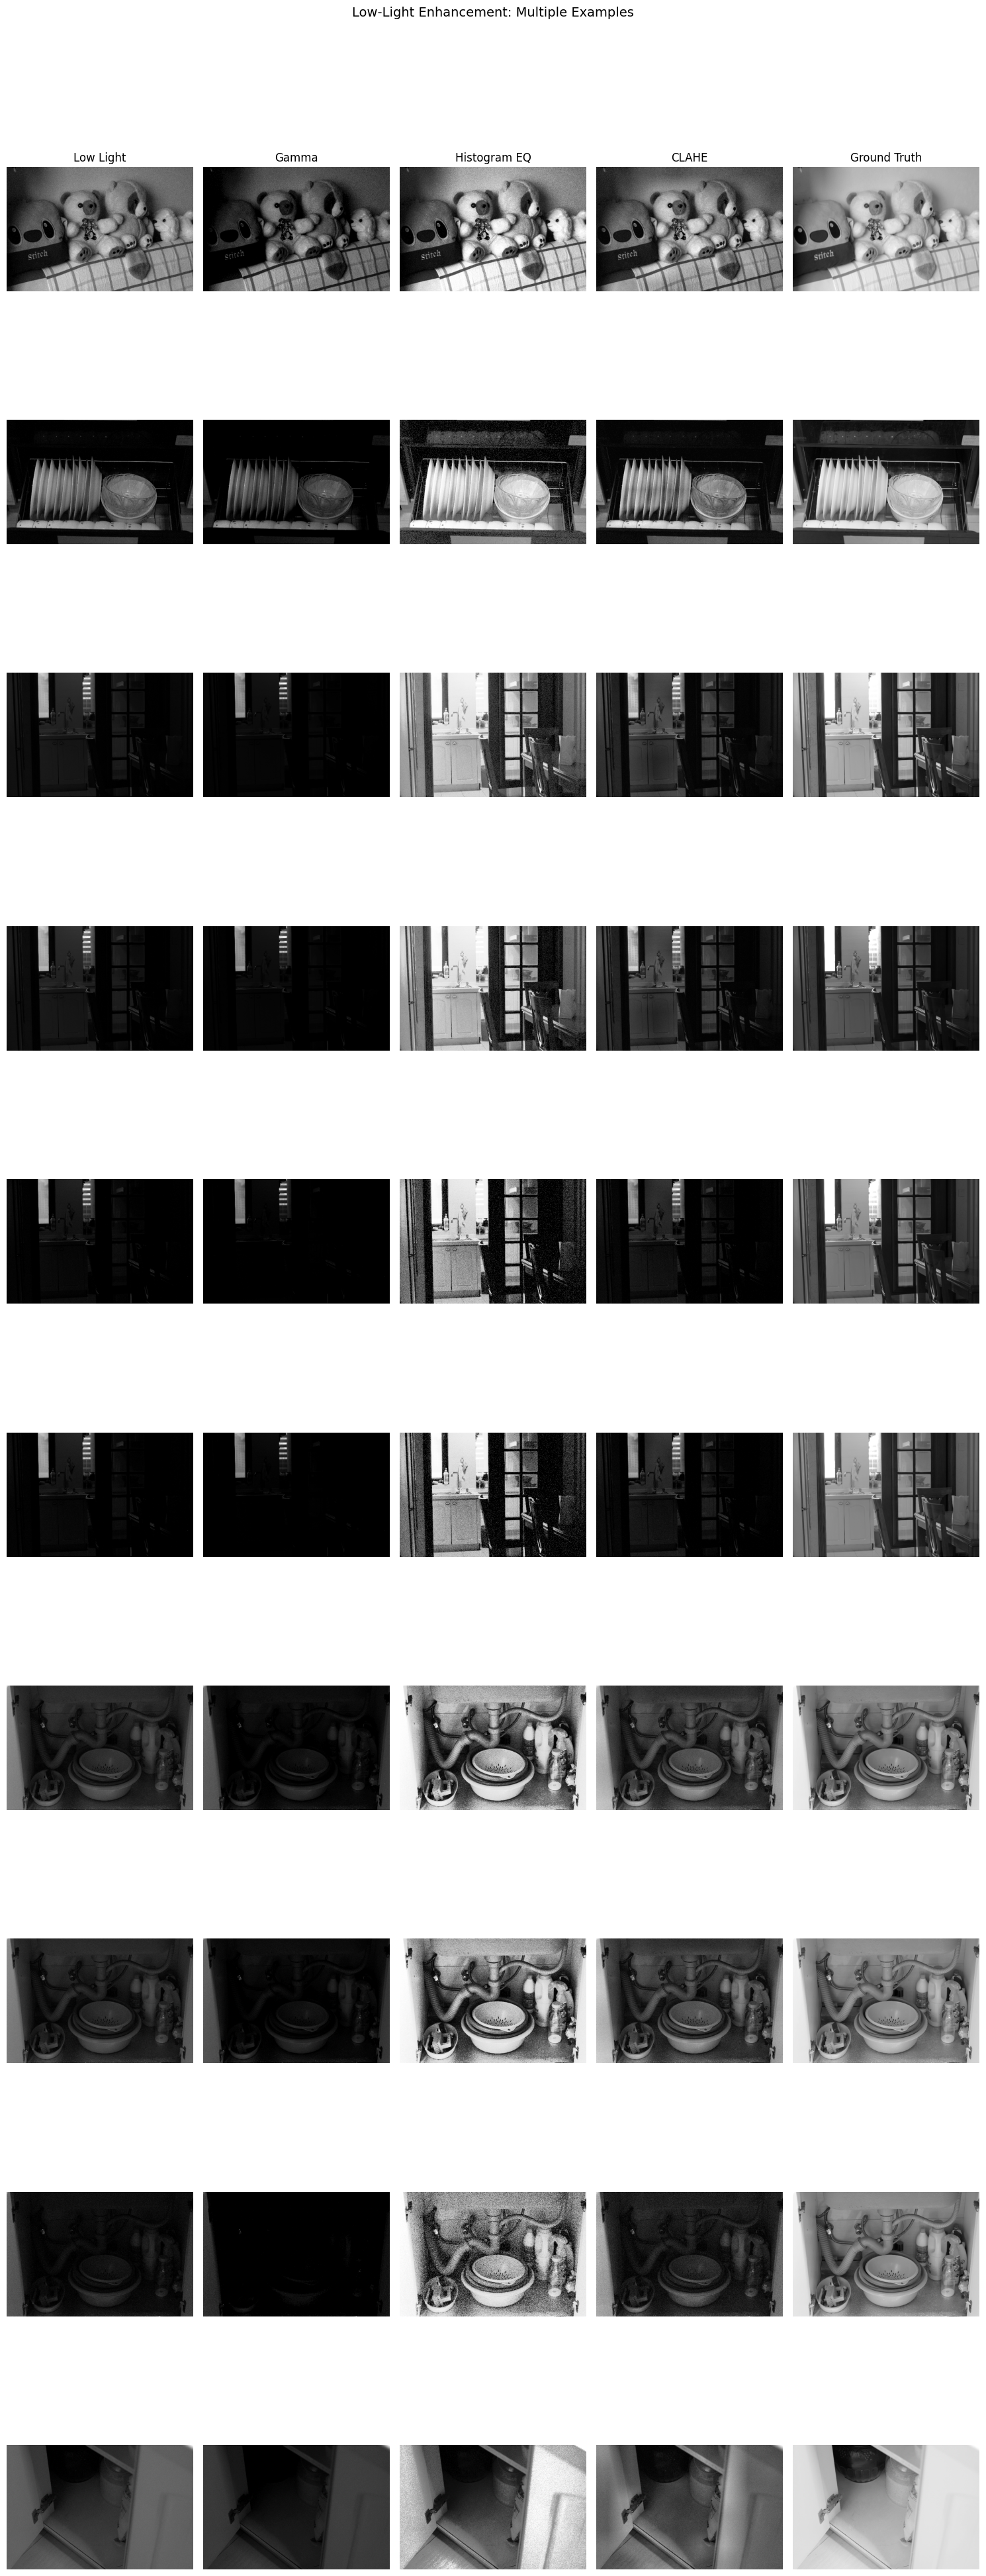

In [ ]:
# Show multiple example images (change N to however many you want)
N =10 # number of examples to display

fig, axes = plt.subplots(N, 5, figsize=(15, 4 * N))

for i, fname in enumerate(FILES[:N]):
    low = cv2.imread(os.path.join(LOW_FOLDER, fname), cv2.IMREAD_GRAYSCALE)
    high = cv2.imread(os.path.join(HIGH_FOLDER, fname), cv2.IMREAD_GRAYSCALE)

    gamma_img = apply_gamma(low, gamma=1.5)
    hist_img = apply_histogram_equalization(low)
    clahe_img = apply_clahe(low)

    images = [low, gamma_img, hist_img, clahe_img, high]
    titles = ['Low Light', 'Gamma', 'Histogram EQ', 'CLAHE', 'Ground Truth']

    for j, (img, title) in enumerate(zip(images, titles)):
        axes[i, j].imshow(img, cmap='gray')
        if i == 0:
            axes[i, j].set_title(title, fontsize=12)
        axes[i, j].set_ylabel(f'Image {i+1}', fontsize=9)
        axes[i, j].axis('off')

plt.suptitle('Low-Light Enhancement: Multiple Examples', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()